---
title: "Wavelets"
---

In [1]:
from scipy.fft import fft, ifft, fftshift, fft2, ifft2
from scipy.signal import stft
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import pywt
from scipy.io.wavfile import read as wave_read
%matplotlib inline 

In [2]:
# We need a tool that converts images into grayscale (i.e. all pixel values in [0, 1])
def gray_scale_convert(image):
    rescaled_image = np.zeros((image.shape[0], image.shape[1]))
    rescaled_image[:, :] = image
    rescaled_image -= np.min(rescaled_image)
    rescaled_image /= np.max(rescaled_image)
    return rescaled_image

## Wavelets

In [23]:
# Perform a wavelet decomposition on the chirp signal

tpi = 2.*np.pi
chirp = lambda t, om0, om1: np.cos(tpi*t*(om0 + (om1-om0)*t**2./(3.*tw**2.)))
f0 = 50 # 50 Hz, 
f1 = 2.*f0 # 100 Hz
#Npts = int(4*f1) # sample at twice the highest frequency
Npts = 2**8 
tw = 1. # this is understood to be 1 second of time
tvals = np.linspace(0., tw, Npts + 1)
chirpvals = chirp(tvals, f0, f1)

levels = 2
wave_fun = 'coif4'
coeffs = pywt.wavedec(chirpvals, wave_fun, level=levels)
print(len(coeffs))


3


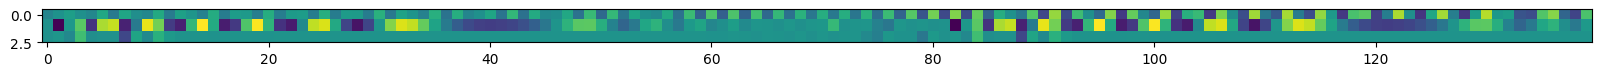

In [24]:
# Plot the multi-resolution analysis represented by the coefficients
fig = plt.figure(figsize=(20,24))
siglength = coeffs[-1].size
coeffsmat = np.zeros((levels+1, siglength))
coeffsmat[0, :] = coeffs[levels]
for jj in range(1, levels):
    if jj < levels-1:
        coeffsmat[jj, :] = np.tile(coeffs[levels-jj], 2**jj)[:siglength]
    else:
        coeffsmat[jj, :] = np.tile(coeffs[levels-jj], 2**jj)[:siglength]
        coeffsmat[jj+1, :] = np.tile(coeffs[levels-jj-1], 2**jj)[:siglength]

plt.imshow(coeffsmat)

In [25]:
detail_recon = [None]*(levels+1)
chirp_details = [None]*(levels+1)
for ll in range(levels+1):
    for jj in range(levels+1):
        if jj == ll:
            detail_recon[ll] = np.array([v for v in coeffs[ll]]) # zero out everything but the approximation coefficients.
        else:
            detail_recon[jj] = np.array([np.zeros_like(v) for v in coeffs[jj]]) # zero out everything but the approximation coefficients.  
    chirp_details[ll] = pywt.waverec(detail_recon, wave_fun)

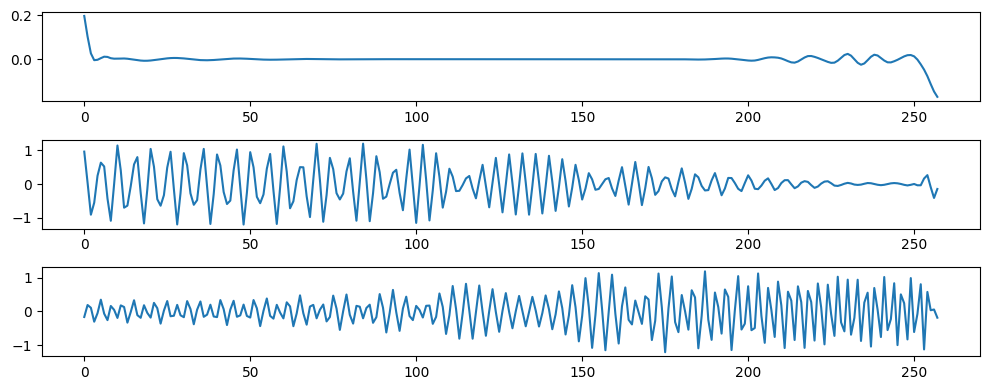

In [26]:
fig, axes = plt.subplots(levels+1, 1, figsize=(10, 4))
ax = axes.ravel()
for jj in range(levels+1):
    ax[jj].plot(chirp_details[jj])
plt.tight_layout()

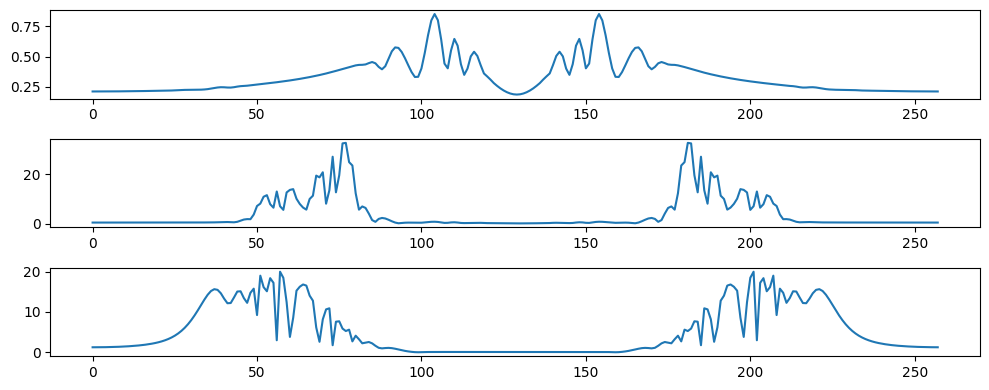

In [27]:
fig, axes = plt.subplots(levels+1, 1, figsize=(10, 4))
ax = axes.ravel()
for jj in range(levels+1):
    chirp_freq = (np.abs( np.fft.fftshift(np.fft.fft(chirp_details[jj])) ))
    ax[jj].plot(chirp_freq)
plt.tight_layout()

# Image Analysis

Now, what happens when we use the 2D FFT on Beans?  

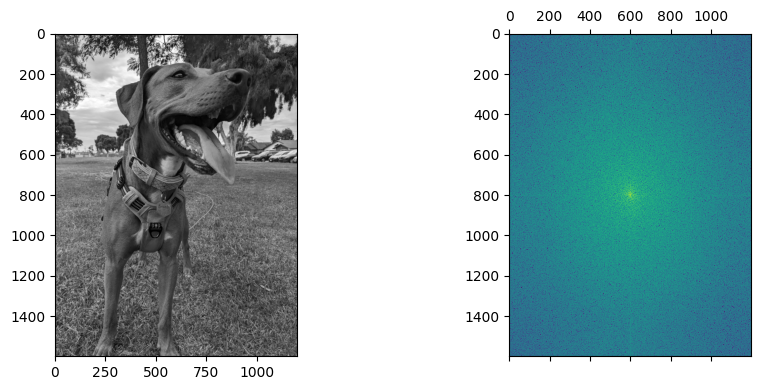

In [28]:
# Find, load, and convert image from textbook data
# Image is in Lecture_Notes folder 
beans = io.imread('beans.jpg', as_gray=True)
beans_freq = np.fft.fft2(beans)
beans_freq_plot = np.log10(fftshift(np.abs(beans_freq)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()

ax[0].imshow(beans, cmap=plt.cm.gray)
ax[1].matshow(beans_freq_plot)

plt.tight_layout()

So, there isn't really any clear interpretation of Beans in the FFT plot to the right.  Nevertheless, we can still do useful things with it.  To wit, we can look at, as you might have guessed, amplitude comparisons and only keep large Fourier coefficients.  

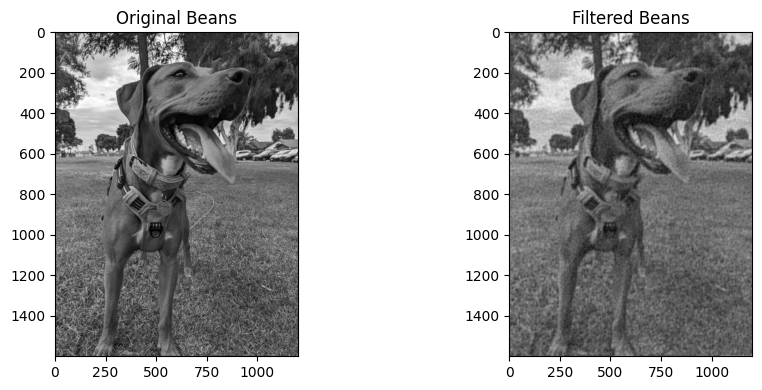

In [29]:
max_freq = np.max(np.abs(beans_freq))
indskp = np.ma.log10(np.abs(beans_freq)/max_freq) >= -3
dog_filter = np.zeros((beans_freq.shape[0], beans_freq.shape[1]), dtype=np.complex128)
dog_filter[indskp] = beans_freq[indskp]
beans_reduced = gray_scale_convert(np.real(ifft2(dog_filter)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()

ax[0].imshow(beans, cmap=plt.cm.gray)
ax[0].set_title("Original Beans")
ax[1].imshow(beans_reduced, cmap=plt.cm.gray)
ax[1].set_title("Filtered Beans")
plt.tight_layout()

So with almost none of the affiliated Fourier spectra, we get a weirdly good recreation of Beans, but in a very different way than what we did with the SVD.  Let's see how the original and altered images look though through that lense.  

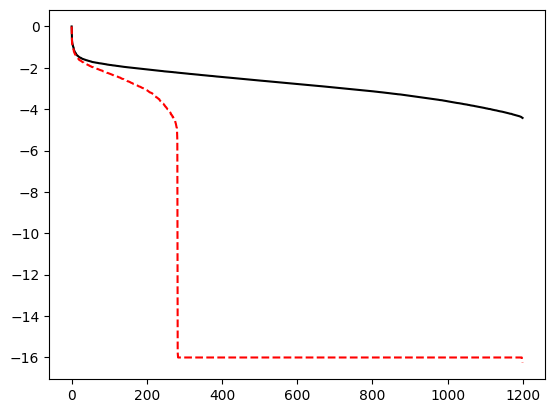

In [30]:
u, s, vh = np.linalg.svd(beans)
ur, sr, vhr = np.linalg.svd(beans_reduced)

plt.plot(np.ma.log10(s/s[0]), color='k')
plt.plot(np.ma.log10(sr/sr[0]), color='r', ls='--')

So we see our FFT based approach is similar to chopping off dimensions in the SVD, though perhaps not quite as systematic in how we can describe the effect. 

In [31]:
levels = 4
print(beans.shape)
coeffs = pywt.wavedec2(beans, 'db1', level=levels) # coeffs = (cA, (cH1, cV1, cD1), (cH2, cV2, cD2), etc...)

(1600, 1200)


In [32]:
nrows, ncols = coeffs[0].shape
print(coeffs[0].shape)

trows = nrows*int(2**levels)
tcols = ncols*int(2**levels)

coeffmat = np.zeros((trows, tcols))

for jj in range(levels+1):
    if jj == 0:
        coeffmat[:nrows , :ncols] = gray_scale_convert(coeffs[jj])
    else:
        sclfac = int(2**(jj-1))
        for ll in range(3):
            coeffmat[:sclfac*nrows, sclfac*ncols:2*sclfac*ncols] = gray_scale_convert(coeffs[jj][ll][:, :])
            coeffmat[sclfac*nrows:2*sclfac*nrows, :sclfac*ncols] = gray_scale_convert(coeffs[jj][ll][:, :])
            coeffmat[sclfac*nrows:2*sclfac*nrows, sclfac*ncols:2*sclfac*ncols] = gray_scale_convert(coeffs[jj][ll][:, :])

(100, 75)


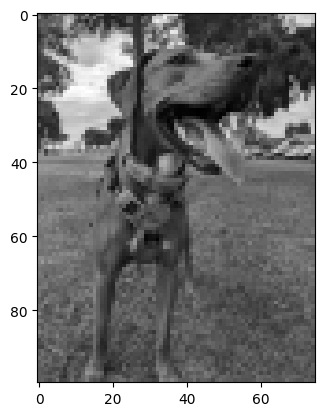

In [33]:
plt.imshow(coeffs[0], interpolation='nearest', cmap=plt.cm.grey)

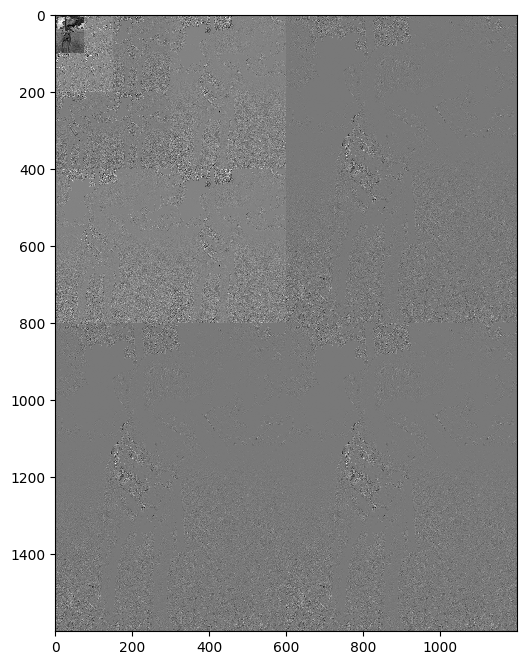

In [34]:
fig, axes = plt.subplots(1, 1, figsize=(10, 8))
axes.imshow(coeffmat, interpolation='nearest', cmap=plt.cm.grey)

In [35]:
recon = [None]*(levels+1)
recon[0] = coeffs[0]
for ll in range(levels):
    recon[ll+1] = tuple([np.zeros_like(v) for v in coeffs[ll+1]]) # zero out everything but the approximation coefficients.  
beans_approx = pywt.waverec2(tuple(recon), 'db1')

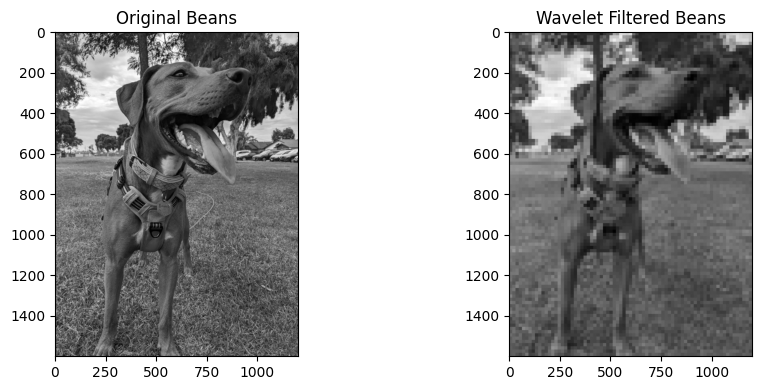

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()
ax[0].imshow(beans, cmap=plt.cm.grey)
ax[0].set_title("Original Beans")
ax[1].imshow(gray_scale_convert(beans_approx), cmap=plt.cm.grey)
ax[1].set_title("Wavelet Filtered Beans")
plt.tight_layout()

In [37]:
detail_recon = [None]*(levels+1)
beans_details = [None]*(levels)
for ll in range(levels):
    for jj in range(levels+1):
        if jj != ll:
            detail_recon[jj] = tuple([np.zeros_like(v) for v in coeffs[jj]]) # zero out everything but the approximation coefficients.  
        else:
            detail_recon[ll] = tuple([v for v in coeffs[ll]]) # zero out everything but the approximation coefficients.
    beans_details[ll] = pywt.waverec2(tuple(detail_recon), 'db1')

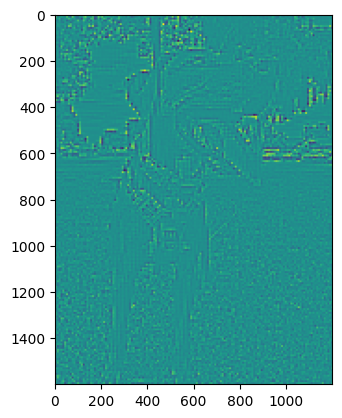

In [39]:
plt.imshow(gray_scale_convert(beans_details[1]))

# Get brightness range - i.e. darkest and lightest pixels
min=np.min(gray_scale_convert(beans_details[0]))        # result=144
max=np.max(gray_scale_convert(beans_details[0]))        # result=216


